In [1]:
from modules.utils import merge_devtest_csvs
from modules.viz import ConfigLookup, metric_x_point, test_summary
from pathlib import Path
import numpy as np
import pandas as pd

In [2]:
# compiling dfs
# folder = Path('./output/2025-12-10_14h50m47s_reconstr_grid_4')
# dev = pd.read_csv(folder/'dev.csv')
# test = pd.read_csv(folder/'test.csv')

folder = Path('./output/reconstr_grid4b')
subfolders = ['t1', 't2', 't3']
dev = merge_devtest_csvs(folder, subfolders, 'dev.csv', save=True)
test = merge_devtest_csvs(folder, subfolders, 'test.csv', save=True)

# get confs, update
confs_class = ConfigLookup(
    keys=['ema_norm','loss_weights'],
    configs=dev['config'].unique().tolist(),
    path=folder,
    save=True,
)

confs = confs_class.data

# merge with confs
dev = pd.merge(confs, dev,on='config')
test = pd.merge(confs, test,on='config')

In [3]:
test['loss_weights'] = test['loss_weights'].astype(str)
test

,ema_norm,loss_weights,config,trial,metric,value
0,True,"[1, 0.0001]",losskwargsEmanormTruelossclassesMSELossKLDLoss...,0,loss,0.770839
1,True,"[1, 0.0001]",losskwargsEmanormTruelossclassesMSELossKLDLoss...,0,mse,0.761529
2,True,"[1, 0.0001]",losskwargsEmanormTruelossclassesMSELossKLDLoss...,0,rmse,0.872656
3,True,"[1, 0.0001]",losskwargsEmanormTruelossclassesMSELossKLDLoss...,0,mae,0.596624
4,True,"[1, 0.0001]",losskwargsEmanormTruelossclassesMSELossKLDLoss...,0,r2,0.801786
...,...,...,...,...,...,...
835,True,"[1, 1e-07]",losskwargsEmanormTruelossclassesMSELossKLDLoss...,29,rmse,0.867900
836,True,"[1, 1e-07]",losskwargsEmanormTruelossclassesMSELossKLDLoss...,29,mae,0.589656
837,True,"[1, 1e-07]",losskwargsEmanormTruelossclassesMSELossKLDLoss...,29,r2,0.807776
838,True,"[1, 1e-07]",losskwargsEmanormTruelossclassesMSELossKLDLoss...,29,kld,138.669510


In [4]:
test_summary(test, save_csv=True, filename=folder/'summary.csv')

,config,metric,mean,sd,ci
0,losskwargsEmanormTruelossclassesMSELossKLDLoss...,kld,3.013884,7.049957,2.632497
1,losskwargsEmanormTruelossclassesMSELossKLDLoss...,loss,0.786072,0.182507,0.068149
2,losskwargsEmanormTruelossclassesMSELossKLDLoss...,mae,0.576946,0.026911,0.010049
3,losskwargsEmanormTruelossclassesMSELossKLDLoss...,mse,0.722482,0.057012,0.021289
4,losskwargsEmanormTruelossclassesMSELossKLDLoss...,r2,0.811669,0.014556,0.005435
5,losskwargsEmanormTruelossclassesMSELossKLDLoss...,rmse,0.849308,0.034600,0.012920
6,losskwargsEmanormTruelossclassesMSELossKLDLoss...,time,255.760923,0.676109,0.252463
7,losskwargsEmanormTruelossclassesMSELossKLDLoss...,kld,52.216353,39.755760,14.845045
8,losskwargsEmanormTruelossclassesMSELossKLDLoss...,loss,0.496567,0.038456,0.014360
9,losskwargsEmanormTruelossclassesMSELossKLDLoss...,mae,0.540678,0.043356,0.016189


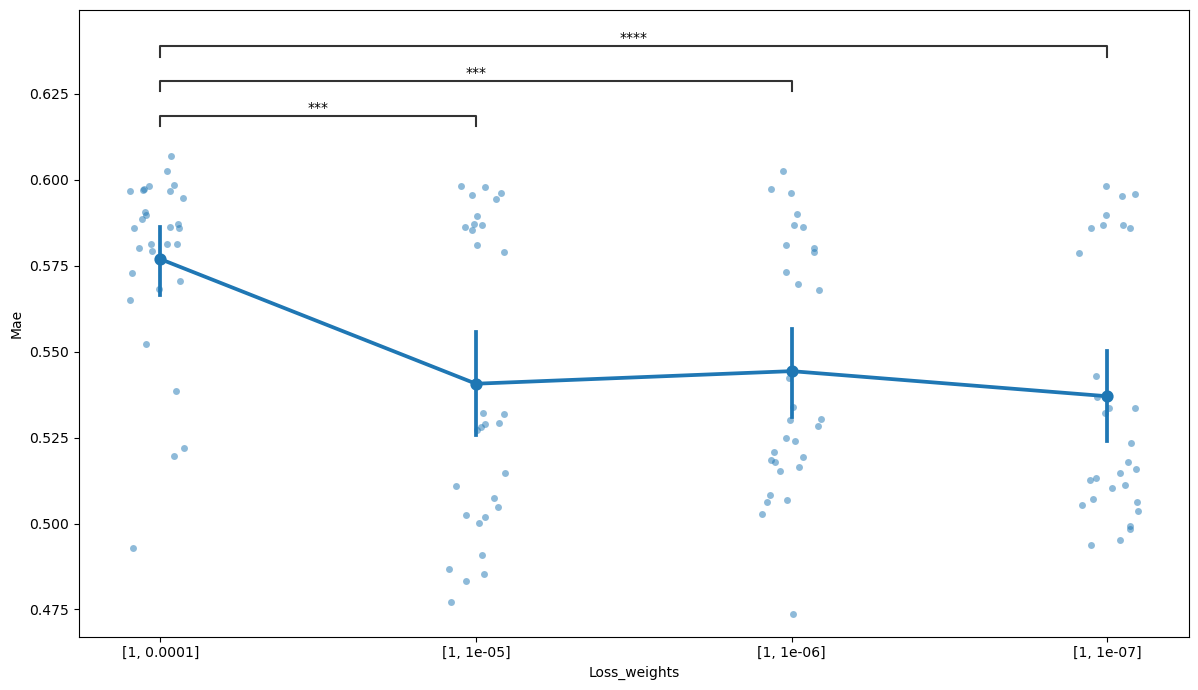

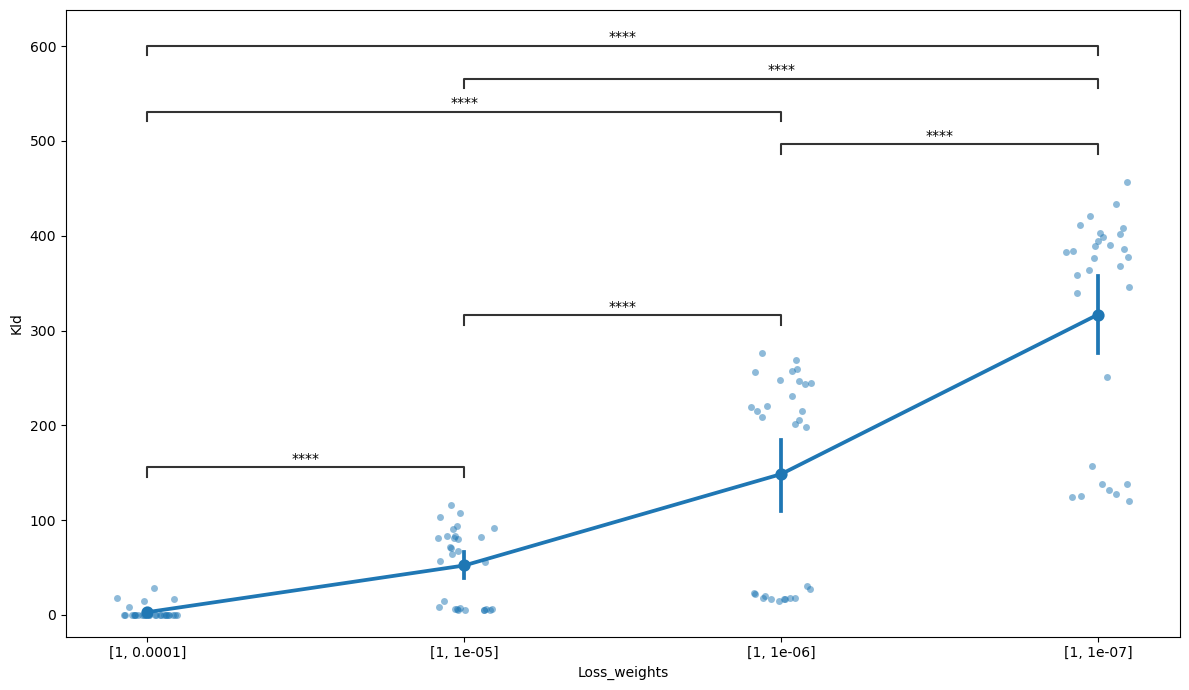

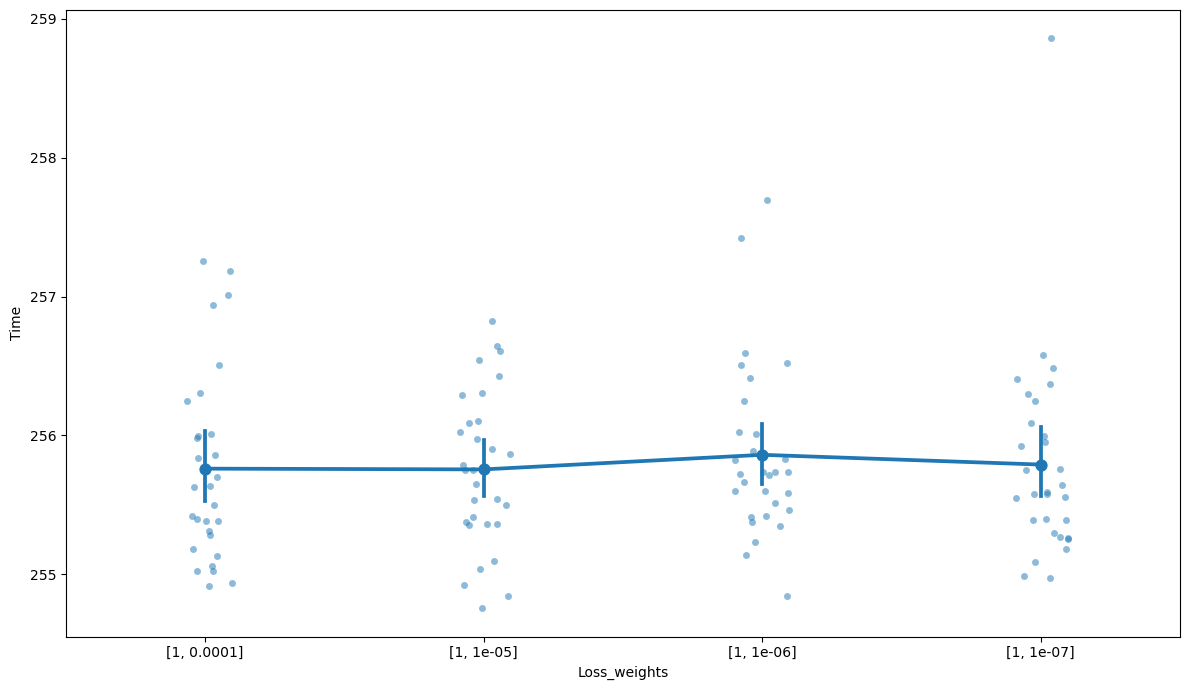

In [5]:
metric_x_point(
    df=test, 
    cols=['loss_weights'],
    metrics=['mae', 'kld', 'time'],
    figsize=(12,7),
    strip=True,
    sig=True
)

In [6]:
from modules.viz import devplot

In [7]:
dev['loss_weights'] = dev['loss_weights'].astype(str)
dev

,ema_norm,loss_weights,config,trial,epoch,stage,metric,value
0,True,"[1, 0.0001]",losskwargsEmanormTruelossclassesMSELossKLDLoss...,0,0,train,loss,0.521759
1,True,"[1, 0.0001]",losskwargsEmanormTruelossclassesMSELossKLDLoss...,0,0,train,mse,0.804809
2,True,"[1, 0.0001]",losskwargsEmanormTruelossclassesMSELossKLDLoss...,0,0,train,rmse,0.897111
3,True,"[1, 0.0001]",losskwargsEmanormTruelossclassesMSELossKLDLoss...,0,0,train,mae,0.610816
4,True,"[1, 0.0001]",losskwargsEmanormTruelossclassesMSELossKLDLoss...,0,0,train,r2,0.788937
...,...,...,...,...,...,...,...,...
287995,True,"[1, 1e-07]",losskwargsEmanormTruelossclassesMSELossKLDLoss...,29,199,val,mse,0.740146
287996,True,"[1, 1e-07]",losskwargsEmanormTruelossclassesMSELossKLDLoss...,29,199,val,rmse,0.860317
287997,True,"[1, 1e-07]",losskwargsEmanormTruelossclassesMSELossKLDLoss...,29,199,val,mae,0.584091
287998,True,"[1, 1e-07]",losskwargsEmanormTruelossclassesMSELossKLDLoss...,29,199,val,r2,0.805908


In [8]:
summary = pd.read_csv(folder/'summary.csv')
summary = pd.merge(confs,summary,on='config')
summary['loss_weights'] = summary['loss_weights'].astype(str)
summary


,ema_norm,loss_weights,config,metric,mean,sd,ci
0,True,"[1, 0.0001]",losskwargsEmanormTruelossclassesMSELossKLDLoss...,kld,3.013884,7.049957,2.632497
1,True,"[1, 0.0001]",losskwargsEmanormTruelossclassesMSELossKLDLoss...,loss,0.786072,0.182507,0.068149
2,True,"[1, 0.0001]",losskwargsEmanormTruelossclassesMSELossKLDLoss...,mae,0.576946,0.026911,0.010049
3,True,"[1, 0.0001]",losskwargsEmanormTruelossclassesMSELossKLDLoss...,mse,0.722482,0.057012,0.021289
4,True,"[1, 0.0001]",losskwargsEmanormTruelossclassesMSELossKLDLoss...,r2,0.811669,0.014556,0.005435
5,True,"[1, 0.0001]",losskwargsEmanormTruelossclassesMSELossKLDLoss...,rmse,0.849308,0.034600,0.012920
6,True,"[1, 0.0001]",losskwargsEmanormTruelossclassesMSELossKLDLoss...,time,255.760923,0.676109,0.252463
7,True,"[1, 1e-05]",losskwargsEmanormTruelossclassesMSELossKLDLoss...,kld,52.216353,39.755760,14.845045
8,True,"[1, 1e-05]",losskwargsEmanormTruelossclassesMSELossKLDLoss...,loss,0.496567,0.038456,0.014360
9,True,"[1, 1e-05]",losskwargsEmanormTruelossclassesMSELossKLDLoss...,mae,0.540678,0.043356,0.016189


In [9]:
figs = devplot(
    dev=dev,
    summary=summary,
    metrics=['mae', 'kld']
)

In [10]:
for key in figs.keys():
    print(key)

losskwargsEmanormTruelossclassesMSELossKLDLosslossweights11e-4
losskwargsEmanormTruelossclassesMSELossKLDLosslossweights11e-5
losskwargsEmanormTruelossclassesMSELossKLDLosslossweights11e-6
losskwargsEmanormTruelossclassesMSELossKLDLosslossweights11e-7


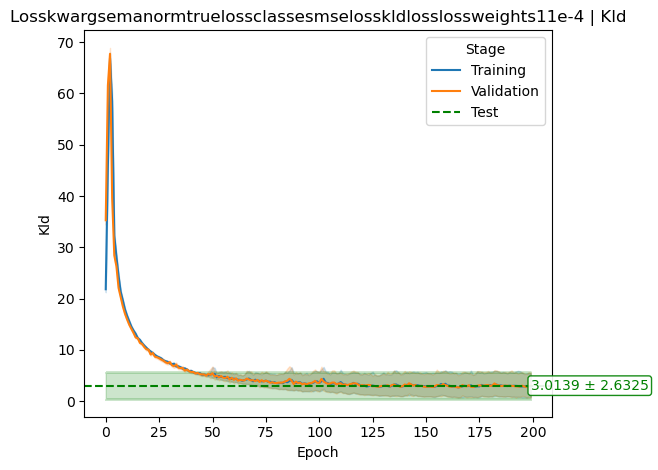

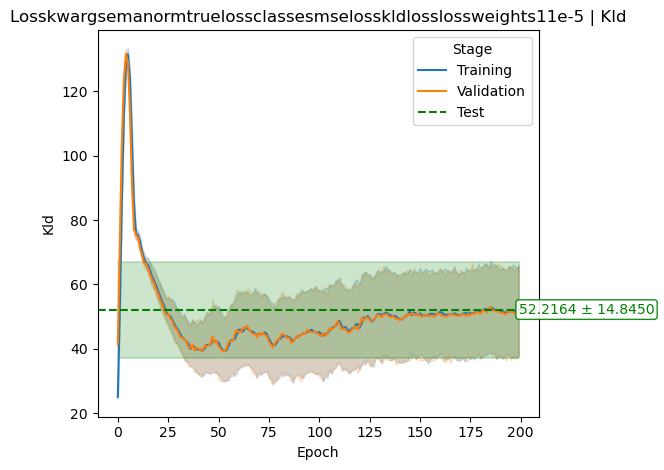

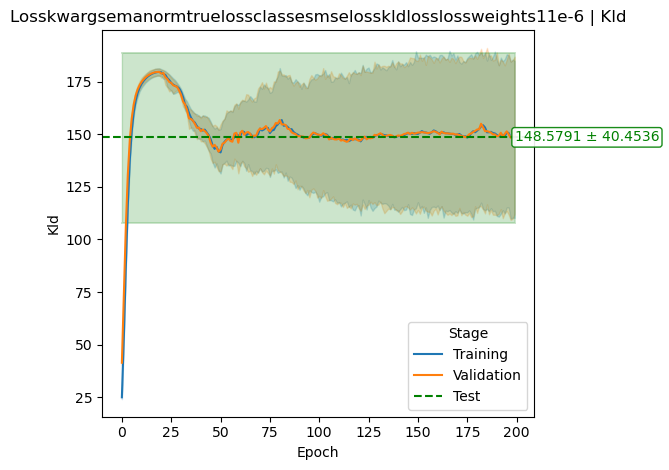

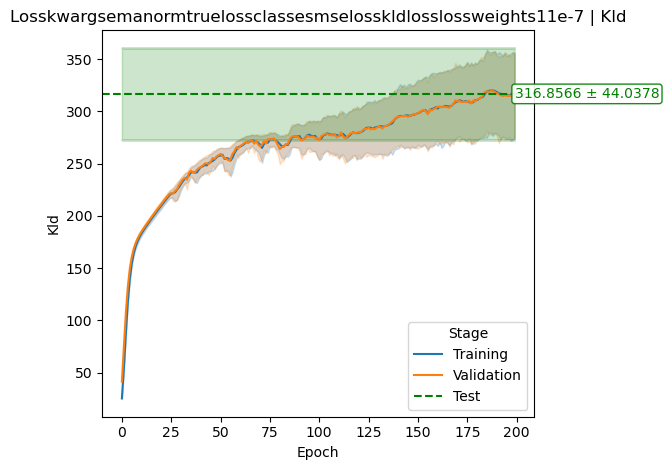

In [11]:
for key in figs.keys():
    display(figs[key]['kld'])

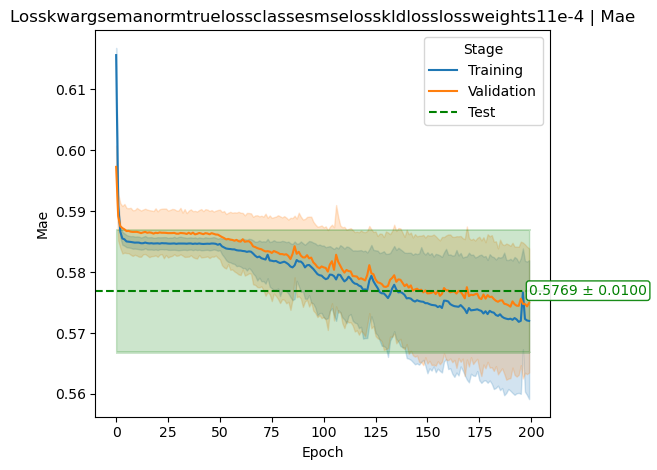

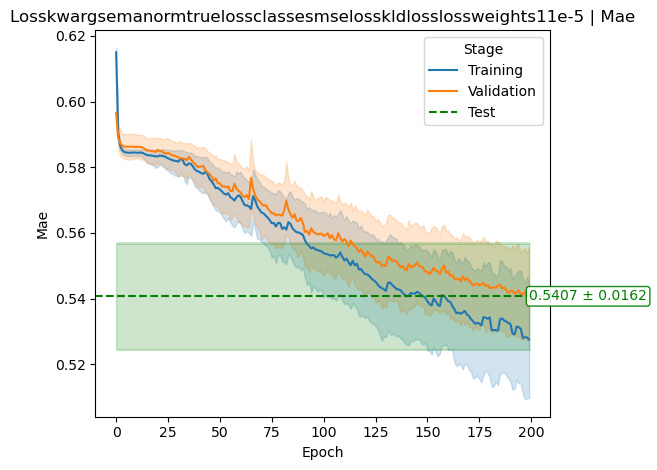

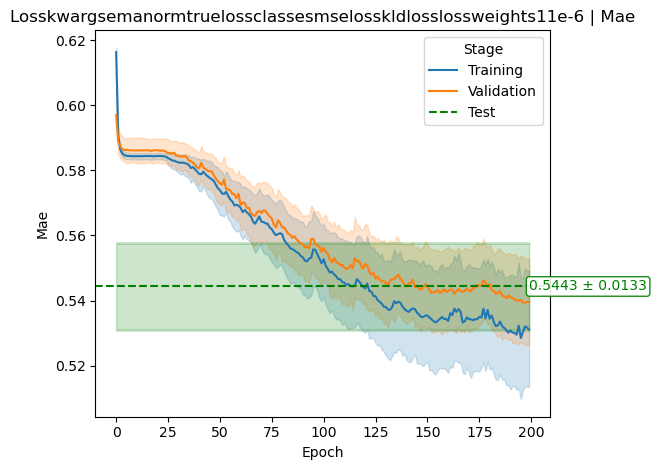

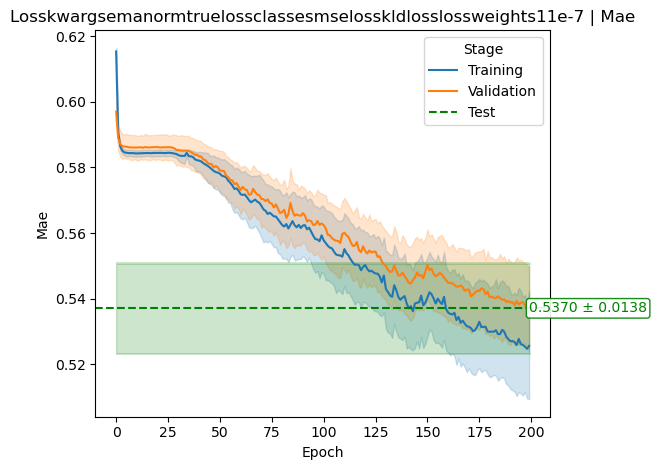

In [12]:
for key in figs.keys():
    display(figs[key]['mae'])